# scVelo
Preliminary experiment to test the functionality of the scVelo method on our data. This is expected NOT to produce sensible velocities.

In [7]:
import scvelo as scv
import anndata as ad
import scanpy as sc

scv.set_figure_params()

In [5]:
python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"
total_counts_path = rf"{python_data_dir}\all_rna_counts_normalized.h5ad"
adata_rna = sc.read_h5ad(total_counts_path)

In [6]:
adata_rna

AnnData object with n_obs × n_vars = 5241 × 6365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'SCT_snn_res.0.8', 'seurat_clusters', 'doublets_normal_cluster_based', 'doublets_random', 'doublets_RNA_consensus', 'nCount_SCT_no_regression', 'nFeature_SCT_no_regression', 'tricyclePosition', 'Phase_tricycle', 'tricycle_fine', 'cell_cycle_atac_classification', 'PromoterPercent', 'immunophenotype_predicted', 'predicted.id', 'prediction.score.LT', 'prediction.score.ST', 'prediction.score.MPP', 'prediction.score.LS_K', 'prediction.score.max', 'Identity_for_diff_testing', 'RF_prediction', 'angle_degree', 'immunophenotype_predicted_cleaned', 'HSC.promoters', 'LMPP.promoters', 'myeloid.promoters', 'MEP.promoters', 'HSC.TSS

In [8]:
# scVelo detects that data has already been normalized and log-transoformed, so it skips this with a warning.
scv.pp.filter_and_normalize(adata_rna)
scv.pp.moments(adata_rna)
scv.tl.velocity(adata_rna, mode='stochastic')

computing neighbors
    finished (0:00:45) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:04) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:05) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [9]:
scv.tl.velocity_graph(adata_rna)

computing velocity graph (using 1/8 cores)


  0%|          | 0/5241 [00:00<?, ?cells/s]

    finished (0:00:30) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


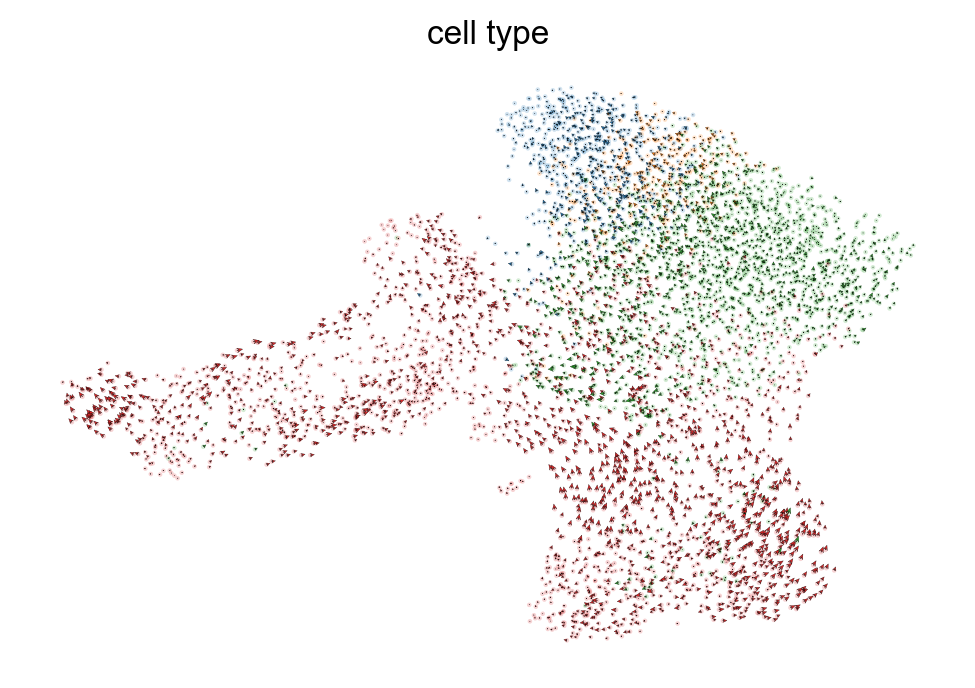

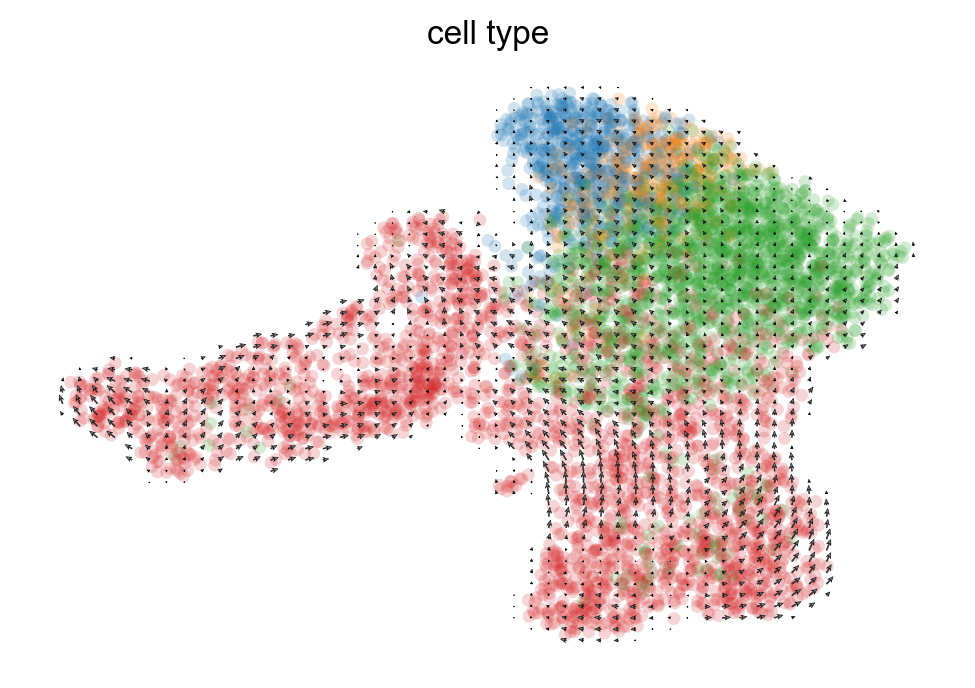

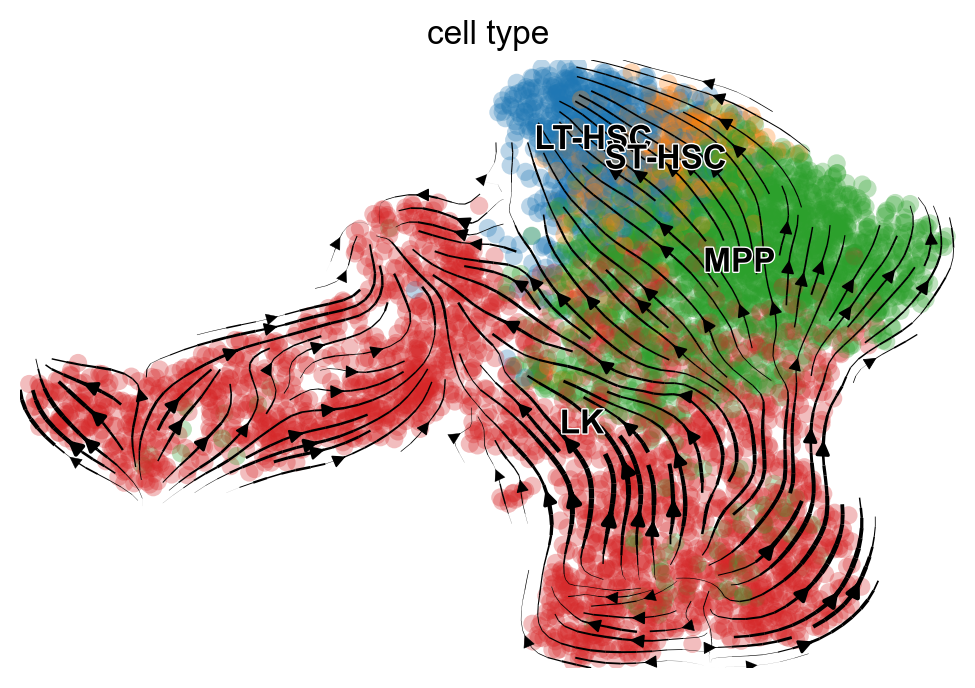

In [10]:
scv.pl.velocity_embedding(adata_rna, basis='umap', color="cell_type")
scv.pl.velocity_embedding_grid(adata_rna, basis='umap', color="cell_type")
scv.pl.velocity_embedding_stream(adata_rna, basis='umap', color="cell_type")

In [11]:
adata_rna.write_h5ad(fr"{python_data_dir}\scvelo_adata_rna.h5ad")